# 0. Setup

In [69]:
import streamlit as st
import fitz
from modules.pdf_parser import extract_text_from_static_pdf
from modules.text_preprocessor import preprocess_text
from modules.qa_engine import generate_answer
from config.settings import TOGETHER_API_KEY, MODEL_NAME_1, MODEL_NAME_2

# Testing
import pandas as pd
from typing import Union, IO
import requests
import time
import json

In [70]:
text = extract_text_from_static_pdf("tests/sample_docs/Sanjay_Prabhu_Kunjibettu_Resume.pdf")
chunks = preprocess_text(text)
full_context = "\n".join(chunks[:15])

In [71]:
models = [MODEL_NAME_1, MODEL_NAME_2]

In [72]:
df_logs = pd.DataFrame()

# 1. Functional Test (Accuracy of Response) & 2. Performance Test

In [73]:
test_1 = [
    ("What is the full name of the person in this document?", ["Sanjay", "Prabhu", "Kunjibettu"]),
    ("What is the current educational qualification being pursued?", ["Masters", "M.Sc.", "Software Technology", "Stuttgart"]),
    ("Where is the person currently working and what are the responsibilities?", ["Mercedes-Benz", "Working Student", "data analysis", "Databricks", "Azure"]),
    ("List some technical skills mentioned in the resume.", ["Python", "Java", "Postgres", "Power BI", "Django", "Flask"]),
    ("Mention any awards or recognitions received by the candidate.", ["Intern of the year", "Team performer", "Project Leader", "Quantiphi"])
]

In [74]:
df_test1 = pd.DataFrame(columns=["Model", "Test Name", "Prompt", "Response", "Response Time", "Pass"])

In [75]:
for _model in models:
    for question, expected_keywords in test_1:
        # print(f"🧪 Question: {question}")
        # print(f"Response: {response}\n")
        # assert any(keyword in response for keyword in expected_keywords), f"❌ Missing expected keywords in: {question}"

        start = time.time() # Performance Testing

        response = generate_answer(full_context, question, _model)

        end = time.time()

        matched = [keyword for keyword in expected_keywords if keyword in response]
        passed = bool(matched) # functional testing

        df_test1 = pd.concat([
            df_test1,
            pd.DataFrame([{
                "Model": _model,
                "Test Name": "Functional and Performance Testing",
                "Prompt": question,
                "Response": response,
                "Response Time": f"{end - start:.2f} seconds",
                "Pass": passed
            }])
        ], ignore_index=True)

        time.sleep(10)

# 3. Consistency Test (Multiple Calls)

In [76]:
df_test3 = pd.DataFrame(columns=["Model", "Test Name", "Prompt", "Response", "Response Time", "Pass"])

In [77]:
responses = []

In [78]:
for _model in models:
    for _attempt in range(3):
        start = time.time() # Performance Testing

        response = generate_answer(full_context, question, _model)

        end = time.time()

        if _attempt==0:
            passed = True
        else:
            passed = response == responses[0]

        responses.append(response)
            
        df_test3 = pd.concat([
            df_test3,
            pd.DataFrame([{
                "Model": _model,
                "Test Name": "Consistency Testing",
                "Prompt": f"{[_attempt]}. question",
                "Response": response,
                "Response Time": f"{end - start:.2f} seconds",
                "Pass": passed
            }])
        ], ignore_index=True)

        time.sleep(10)

* Rate Limit Specifications
- meta-llama: 6 queries/minute, 60000 tokens per minute

# 4. Prompt Variation Test (Robustness)

In [79]:
# pip install sentence-transformers scikit-learn

In [80]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [81]:
# Load once globally
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def semantic_similarity(text1: str, text2: str) -> float:
    embeddings = embedder.encode([text1, text2])
    similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return round(similarity, 4)

In [82]:
df_test4 = pd.DataFrame(columns=["Model", "Test Name", "Prompt", "Response", "Response Time", "Pass"])

In [83]:
# Paraphrased prompts with the same intent
variations = [
    "Who is the person mentioned?",
    "Please tell me the candidate's name.",
    "Can you identify the individual in the document?"
]

reference_prompt = "What is the full name of the person in this document?"

responses = []

In [84]:
for _model in models:
    # Generate a reference response using a known standard prompt
    reference_response = generate_answer(full_context, reference_prompt, _model)

    time.sleep(10)  # delay to respect rate limits

    for question in variations:
        start = time.time()
        response = generate_answer(full_context, question, _model)
        end = time.time()

        # Check if the variation response matches the reference response
        similarity_score = semantic_similarity(response, reference_response)

        df_test4 = pd.concat([
            df_test4,
            pd.DataFrame([{
                "Model": _model,
                "Test Name": "Prompt Variation Testing",
                "Prompt": question,
                "Response": response,
                "Response Time": f"{end - start:.2f} seconds",
                "Pass": similarity_score
            }])
        ], ignore_index=True)

        time.sleep(10)  # delay to respect rate limits

C:\Users\sanja\AppData\Local\Temp\ipykernel_17152\2138002223.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_test4 = pd.concat([


To summarize your six tests in a clear, scientific, and academically sound manner for your Master’s thesis, follow a structure that highlights:

Purpose of each test

Methodology used

Metrics evaluated

Tools used

Key observations (optional)

✅ Suggested Summary Format for Thesis (e.g., in "Evaluation Methodology" Chapter)
6. Evaluation Strategy for Context-Aware Chatbot
The chatbot was evaluated using a systematic testing strategy focused on performance, robustness, and consistency. Six tests were designed and executed, all within a controlled Jupyter notebook environment using Python, LangChain, and Together AI’s free-tier LLMs.

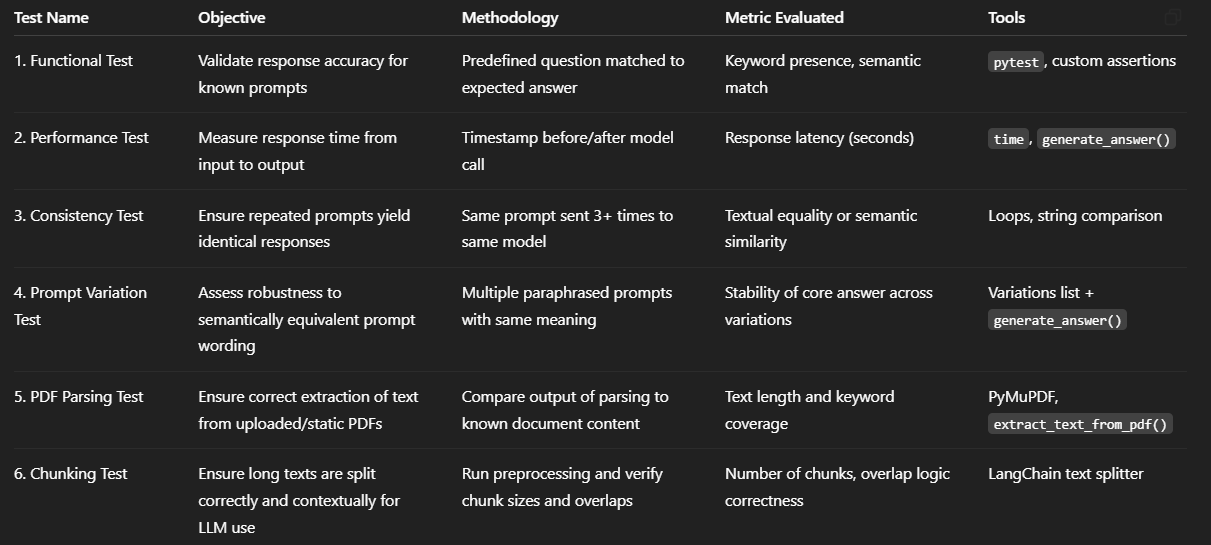

✅ Optional Section: Notes on Limitations
Token limits enforced by Together API required careful chunk size tuning.

Free-tier LLMs (Meta LLaMA 3.3 Turbo and DeepSeek R1 Distill LLaMA 70B) had occasional variability in output.

API rate limits (e.g., 1 request/minute) were handled with manual time.sleep() to ensure fair evaluation.

✅ Scientific Style Tips
Use passive voice where required: "The chatbot was evaluated using..."

Use precise language: "response latency was measured in seconds..."

Cite any tools: e.g., PyMuPDF, LangChain, and Together.ai.

